# EDA — Índice de Marginación Municipal 2020
**Fuente:** CONAPO · `data/raw/indice_marginacion_municipal_2020.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

# ── Estilo ────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "figure.facecolor": "white",
                     "axes.facecolor": "white", "font.size": 11})

DATA_RAW = Path("../data/raw")
df = pd.read_csv(DATA_RAW / "imm_2020-3.csv", encoding="utf-8")
print(f"Forma: {df.shape}  |  Columnas: {list(df.columns)}")
df.head(3)

Forma: (2469, 17)  |  Columnas: ['CVE_ENT', 'NOM_ENT', 'CVE_MUN', 'NOM_MUN', 'POB_TOT', 'ANALF', 'SBASC', 'OVSDE', 'OVSEE', 'OVSAE', 'OVPT', 'VHAC', 'PL.5000', 'PO2SM', 'IM_2020', 'GM_2020', 'IMN_2020']


,CVE_ENT,NOM_ENT,CVE_MUN,NOM_MUN,POB_TOT,ANALF,SBASC,OVSDE,OVSEE,OVSAE,OVPT,VHAC,PL.5000,PO2SM,IM_2020,GM_2020,IMN_2020
0,1,Aguascalientes,1001,Aguascalientes,948990,1.644738,20.367220,0.104799,0.113169,0.378610,0.591434,10.339530,7.523683,54.226594,60.318795,Muy bajo,0.944508
1,1,Aguascalientes,1002,Asientos,51536,3.526405,33.906364,2.650373,0.486448,0.858160,1.352430,22.942305,78.221049,78.565471,56.546071,Muy bajo,0.885433
2,1,Aguascalientes,1003,Calvillo,58250,4.491509,42.482450,0.365177,0.516760,0.800978,1.040411,19.219858,51.301288,79.259777,57.058251,Muy bajo,0.893453


In [2]:
from pathlib import Path

# ── Carpeta de figuras (Cookiecutter: reports/figures/) ──────────────
FIGURES_DIR = Path("../reports/figures/marginacion")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figuras se guardarán en: {FIGURES_DIR.resolve()}")

Figuras se guardarán en: /home/dreamlap/Documents/UNISON/maestria/semestre 2 /AAA/proyecto_AAA_2026-1_equipo4/reports/figures/marginacion


## 1. Información general del dataset

In [3]:
print("─" * 55)
print(f"  Municipios totales : {len(df):,}")
print(f"  Columnas           : {df.shape[1]}")
print(f"  Valores nulos      : {df.isnull().sum().sum()}")
print("─" * 55)
display(df.dtypes.rename("tipo"))
display(df.describe().round(2))

───────────────────────────────────────────────────────
  Municipios totales : 2,469
  Columnas           : 17
  Valores nulos      : 0
───────────────────────────────────────────────────────


CVE_ENT       int64
NOM_ENT         str
CVE_MUN       int64
NOM_MUN         str
POB_TOT       int64
ANALF       float64
SBASC       float64
OVSDE       float64
OVSEE       float64
OVSAE       float64
OVPT        float64
VHAC        float64
PL.5000     float64
PO2SM       float64
IM_2020     float64
GM_2020         str
IMN_2020    float64
Name: tipo, dtype: object

,CVE_ENT,CVE_MUN,POB_TOT,ANALF,SBASC,OVSDE,OVSEE,OVSAE,OVPT,VHAC,PL.5000,PO2SM,IM_2020,IMN_2020
count,2469.00,2469.00,2469.00,2469.00,2469.00,2469.00,2469.00,2469.00,2469.00,2469.00,2469.00,2469.00,2469.00,2469.00
mean,19.22,19324.16,51038.49,10.16,45.85,3.16,1.50,6.12,7.99,26.57,69.90,82.14,53.96,0.84
std,7.37,7382.89,146990.73,7.63,13.98,5.29,2.77,9.25,8.97,10.59,35.27,11.83,3.90,0.06
min,1.00,1001.00,81.00,0.35,5.54,0.00,0.00,0.00,0.00,3.95,0.00,28.45,21.41,0.34
25%,14.00,14079.00,4489.00,4.43,35.74,0.65,0.37,0.88,1.65,18.73,40.13,74.62,51.84,0.81
50%,20.00,20226.00,13552.00,8.20,46.34,1.43,0.83,2.45,4.71,25.00,100.00,84.64,54.42,0.85
75%,24.00,24027.00,35284.00,13.79,55.86,3.34,1.68,7.29,11.03,32.82,100.00,91.62,56.70,0.89
max,32.00,32058.00,1922523.00,53.07,88.33,64.45,53.07,81.79,68.15,69.56,100.00,100.00,62.40,0.98


## 2. Variables del dataset

| Columna | Descripción |
|---|---|
| `ANALF` | % analfabetismo |
| `SBASC` | % sin educación básica |
| `OVSDE` | % viviendas sin drenaje |
| `OVSEE` | % viviendas sin electricidad |
| `OVSAE` | % viviendas sin agua entubada |
| `OVPT` | % viviendas con piso de tierra |
| `VHAC` | % viviendas con hacinamiento |
| `PL.5000` | % población en localidades <5000 hab |
| `PO2SM` | % ocupados con ingreso ≤2 salarios mínimos |
| `IM_2020` | Índice de marginación (mayor = menos marginado) |
| `GM_2020` | Grado de marginación (categórico) |
| `IMN_2020` | Índice de marginación normalizado [0,1] |

## 3. Distribución del grado de marginación

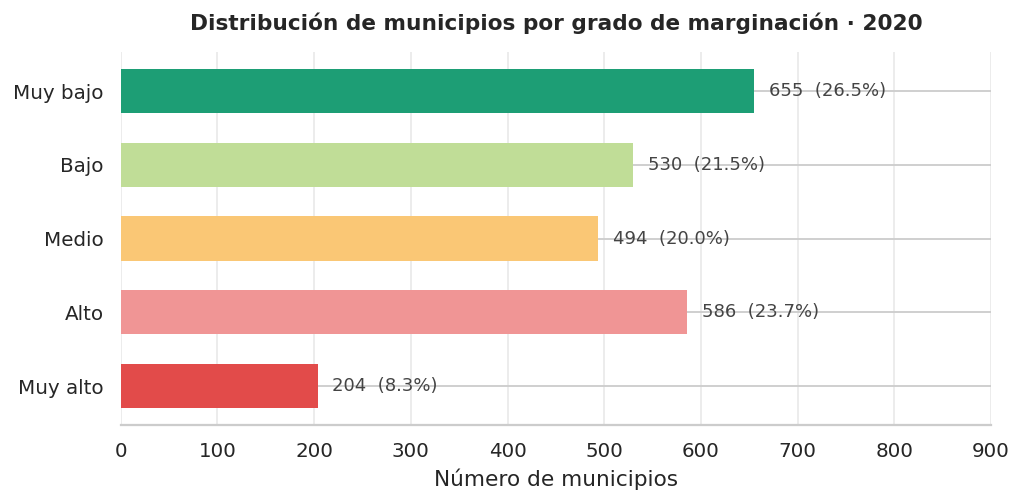

GM_2020
Muy alto    204
Alto        586
Medio       494
Bajo        530
Muy bajo    655


In [4]:
orden = ["Muy alto", "Alto", "Medio", "Bajo", "Muy bajo"]
colores = ["#E24B4A", "#F09595", "#FAC775", "#C0DD97", "#1D9E75"]

conteos = df["GM_2020"].value_counts().reindex(orden)
pcts = (conteos / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(orden, conteos.values, color=colores, height=0.6, edgecolor="none")

for bar, pct, cnt in zip(bars, pcts.values, conteos.values):
    ax.text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2,
            f"{cnt:,}  ({pct}%)", va="center", fontsize=10, color="#444")

ax.set_xlabel("Número de municipios")
ax.set_title("Distribución de municipios por grado de marginación · 2020", fontweight="bold", pad=12)
ax.set_xlim(0, 900)
ax.grid(axis="x", alpha=0.4)
ax.spines[["top","right","left"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_marg_01_grado.png", dpi=130, bbox_inches="tight")
plt.show()
print(conteos.to_string())

## 4. Histogramas de variables socioeconómicas

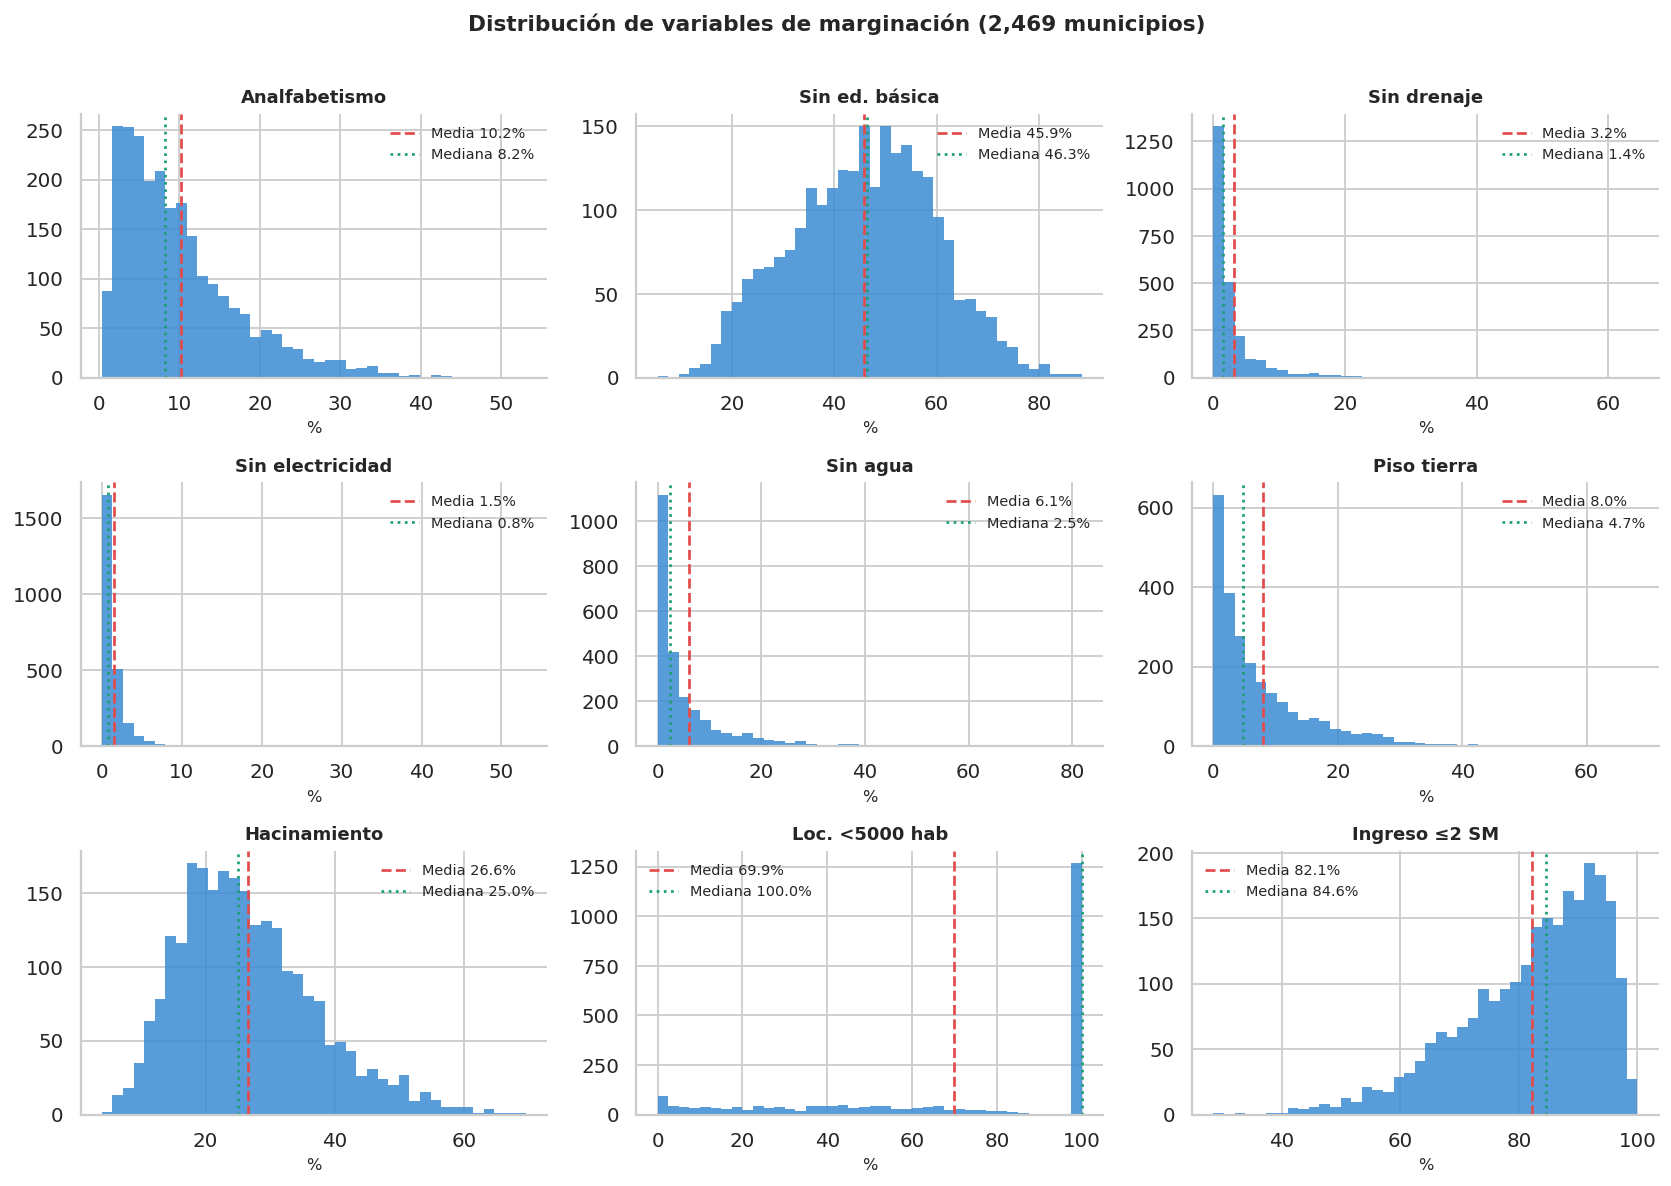

In [5]:
vars_num = ["ANALF", "SBASC", "OVSDE", "OVSEE", "OVSAE", "OVPT", "VHAC", "PL.5000", "PO2SM"]
labels  = ["Analfabetismo", "Sin ed. básica", "Sin drenaje", "Sin electricidad",
           "Sin agua", "Piso tierra", "Hacinamiento", "Loc. <5000 hab", "Ingreso ≤2 SM"]

fig, axes = plt.subplots(3, 3, figsize=(13, 9))
axes = axes.flatten()

for ax, col, lab in zip(axes, vars_num, labels):
    ax.hist(df[col].dropna(), bins=40, color="#3B8BD4", edgecolor="none", alpha=0.85)
    ax.axvline(df[col].mean(),  color="#E24B4A", lw=1.5, ls="--", label=f"Media {df[col].mean():.1f}%")
    ax.axvline(df[col].median(), color="#1D9E75", lw=1.5, ls=":",  label=f"Mediana {df[col].median():.1f}%")
    ax.set_title(lab, fontsize=10, fontweight="bold")
    ax.set_xlabel("%", fontsize=9)
    ax.legend(fontsize=8, frameon=False)
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Distribución de variables de marginación (2,469 municipios)", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_marg_02_histogramas.png", dpi=130, bbox_inches="tight")
plt.show()

## 5. Matriz de correlación entre variables

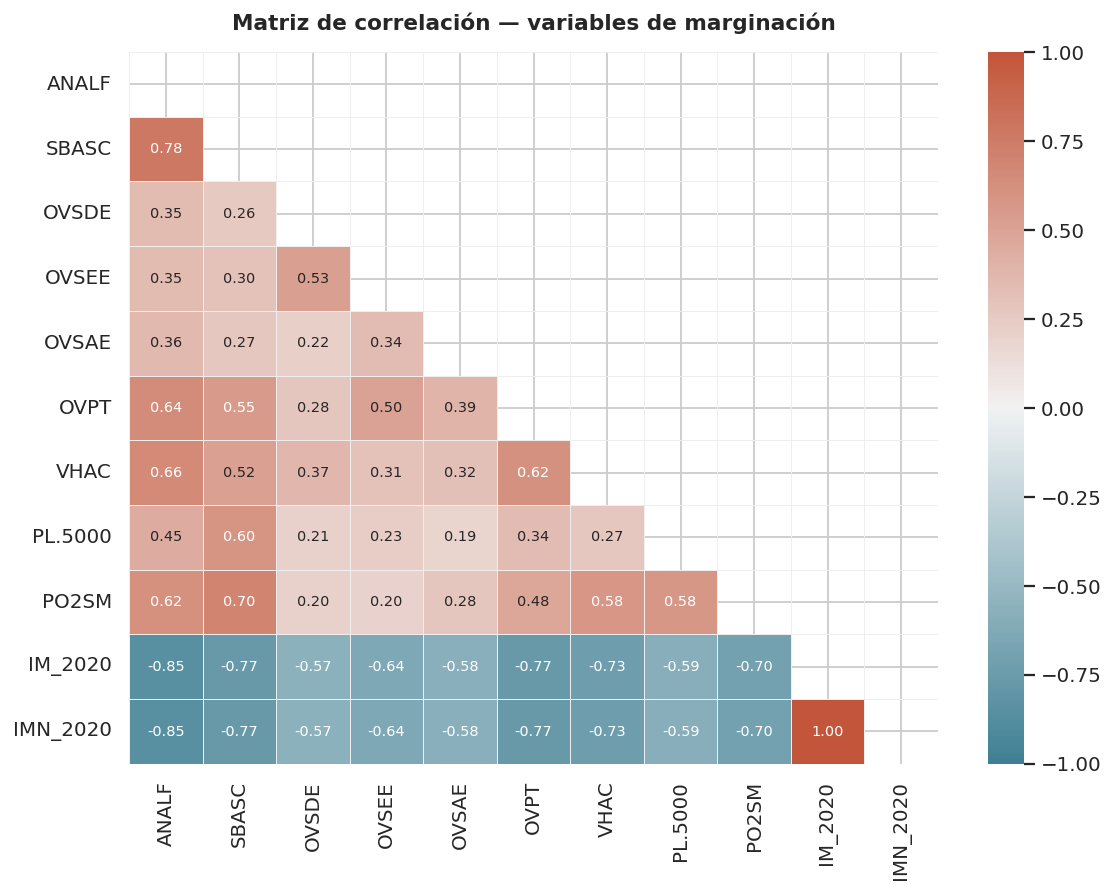

In [6]:
fig, ax = plt.subplots(figsize=(9, 7))

corr = df[vars_num + ["IM_2020", "IMN_2020"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0,
            annot=True, fmt=".2f", linewidths=.4, linecolor="#eee",
            annot_kws={"size": 8}, ax=ax)

ax.set_title("Matriz de correlación — variables de marginación", fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_marg_03_correlacion.png", dpi=130, bbox_inches="tight")
plt.show()

## 6. Análisis para Sonora (CVE_ENT = 26)

In [7]:
son = df[df["CVE_ENT"] == 26].copy()
print(f"Municipios en Sonora: {len(son)}")
print(f"\nGrado de marginación en Sonora:")
print(son["GM_2020"].value_counts().reindex(orden).fillna(0).astype(int).to_string())
print(f"\nEstadísticas Sonora vs Nacional:")

comparativo = pd.DataFrame({
    "Nacional": df[vars_num].mean(),
    "Sonora":   son[vars_num].mean()
}).round(2)
comparativo["Diferencia"] = (comparativo["Sonora"] - comparativo["Nacional"]).round(2)
comparativo.index = labels
display(comparativo)

Municipios en Sonora: 72

Grado de marginación en Sonora:
GM_2020
Muy alto     0
Alto         1
Medio        4
Bajo        17
Muy bajo    50

Estadísticas Sonora vs Nacional:


,Nacional,Sonora,Diferencia
Analfabetismo,10.16,3.20,-6.96
Sin ed. básica,45.85,37.15,-8.70
Sin drenaje,3.16,1.27,-1.89
Sin electricidad,1.50,1.32,-0.18
Sin agua,6.12,1.20,-4.92
Piso tierra,7.99,2.26,-5.73
Hacinamiento,26.57,15.43,-11.14
Loc. <5000 hab,69.90,71.49,1.59
Ingreso ≤2 SM,82.14,71.08,-11.06


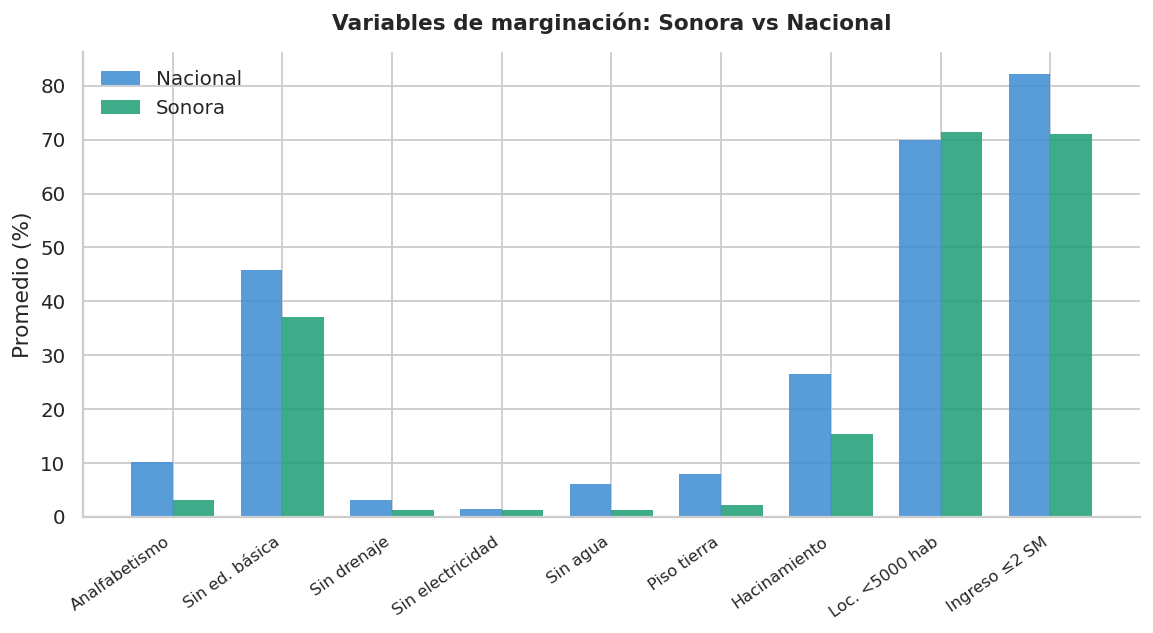

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(labels))
w = 0.38
b1 = ax.bar(x - w/2, df[vars_num].mean(), w, label="Nacional", color="#3B8BD4", alpha=0.85, edgecolor="none")
b2 = ax.bar(x + w/2, son[vars_num].mean(), w, label="Sonora",   color="#1D9E75", alpha=0.85, edgecolor="none")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Promedio (%)")
ax.set_title("Variables de marginación: Sonora vs Nacional", fontweight="bold", pad=12)
ax.legend(frameon=False)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_marg_04_sonora_vs_nacional.png", dpi=130, bbox_inches="tight")
plt.show()

## 7. Top municipios más y menos marginados

In [9]:
top5_mas  = df.nsmallest(5, "IM_2020")[["NOM_ENT","NOM_MUN","IM_2020","GM_2020"]]
top5_menos = df.nlargest(5, "IM_2020")[["NOM_ENT","NOM_MUN","IM_2020","GM_2020"]]

print("── 5 municipios con MAYOR marginación (menor IM_2020) ──")
display(top5_mas.reset_index(drop=True))
print("\n── 5 municipios con MENOR marginación (mayor IM_2020) ──")
display(top5_menos.reset_index(drop=True))

── 5 municipios con MAYOR marginación (menor IM_2020) ──


,NOM_ENT,NOM_MUN,IM_2020,GM_2020
0,Chihuahua,Batopilas de Manuel Gómez Morín,21.406635,Muy alto
1,Durango,Mezquital,28.222995,Muy alto
2,Nayarit,Del Nayar,28.670142,Muy alto
3,Jalisco,Mezquitic,31.305668,Muy alto
4,Guerrero,Cochoapa el Grande,32.205441,Muy alto



── 5 municipios con MENOR marginación (mayor IM_2020) ──


,NOM_ENT,NOM_MUN,IM_2020,GM_2020
0,Ciudad de México,Benito Juárez,62.397145,Muy bajo
1,Nuevo León,San Pedro Garza García,61.845548,Muy bajo
2,Nuevo León,San Nicolás de los Garza,61.418383,Muy bajo
3,Ciudad de México,Cuauhtémoc,61.328534,Muy bajo
4,Nuevo León,Apodaca,61.315874,Muy bajo


## 8. Conclusiones del EDA — Marginación

- **Sin valores nulos** en los 2,469 municipios.
- La distribución de grados es: Muy bajo (655) > Alto (586) > Bajo (530) > Medio (494) > Muy alto (204).
- `ANALF` y `PO2SM` tienen las distribuciones más sesgadas a la derecha — hay municipios con valores extremos.
- `PO2SM` (ingresos bajos) es la variable con mayor correlación con pobreza (**r = 0.814**).
- **Sonora** tiene marginación notablemente menor que la media nacional en casi todas las variables.
- Municipios más marginados se concentran en **Chihuahua, Durango, Nayarit, Guerrero y Oaxaca**.
- Para el modelo: usar `ANALF`, `SBASC`, `PO2SM`, `VHAC`, `OVPT` como variables independientes principales.